In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# PHASE - 1 > [ Feature Enginerring )

In [2]:
# Import - healthcare_fraud_deduction_dataset

health = pd.read_csv(r'healthcare_fraud_detections.csv')

In [3]:
# Overview of the dataset 
health.head(4)

,Provider_ID,Claim_ID,Patient_Age,Patient_Gender,Diagnosis_Code,Procedure_Code,Claim_Amount,Approved_Amount,Insurance_Type,Claim_Submission_Date,Days_Between_Service_and_Claim,Number_of_Claims_Per_Provider_Monthly,Provider_Specialty,Patient_State,Claim_Status,Is_Fraud,Length_of_Stay,Visit_Type,Chronic_Condition_Flag,Prior_Visits_12m
0,P0052,C0000000,37,Male,I25.10,36415,443.51,393.16,Medicaid,2024-09-01,13,70,Cardiology,NY,Approved,0,0,Outpatient,1,2.0
1,P0121,C0000001,21,Female,E11.9,99213,467.50,461.33,Self-Pay,2022-09-05,5,62,General Practice,IL,Pending,0,5,Inpatient,1,2.0
2,P0140,C0000002,78,Female,J06.9,93000,591.69,530.06,Medicaid,2022-04-11,29,60,Cardiology,IL,Pending,0,5,Inpatient,1,3.0
3,P0202,C0000003,65,Male,I10,93000,235.15,189.11,Private,2023-10-11,22,70,General Practice,TX,Approved,0,0,Emergency,0,5.0


In [4]:
# shape of the dataset
health.shape

(10000, 20)

In [5]:
# information of dataset & types 
health.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 20 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Provider_ID                            10000 non-null  object 
 1   Claim_ID                               10000 non-null  object 
 2   Patient_Age                            10000 non-null  int64  
 3   Patient_Gender                         10000 non-null  object 
 4   Diagnosis_Code                         10000 non-null  object 
 5   Procedure_Code                         10000 non-null  int64  
 6   Claim_Amount                           10000 non-null  float64
 7   Approved_Amount                        10000 non-null  float64
 8   Insurance_Type                         9650 non-null   object 
 9   Claim_Submission_Date                  10000 non-null  object 
 10  Days_Between_Service_and_Claim         10000 non-null  int64  
 11  Num

In [6]:
# Describe of the dataset 
health.describe()

,Patient_Age,Procedure_Code,Claim_Amount,Approved_Amount,Days_Between_Service_and_Claim,Number_of_Claims_Per_Provider_Monthly,Is_Fraud,Length_of_Stay,Chronic_Condition_Flag,Prior_Visits_12m
count,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,9650.000000
mean,49.755000,86905.21170,572.804406,475.514157,14.413800,68.628000,0.082900,2.19930,0.292000,3.026425
std,17.910144,14965.32496,406.202437,323.257165,8.489875,14.905872,0.275745,1.71046,0.454705,1.722789
min,1.000000,36415.00000,60.210000,50.350000,0.000000,42.000000,0.000000,0.00000,0.000000,0.000000
25%,37.750000,80053.00000,305.205000,257.200000,7.000000,60.000000,0.000000,1.00000,0.000000,2.000000
50%,50.000000,93000.00000,461.225000,388.370000,14.000000,66.000000,0.000000,2.00000,0.000000,3.000000
75%,62.000000,99213.00000,711.365000,598.347500,22.000000,72.000000,0.000000,3.00000,1.000000,4.000000
max,95.000000,99214.00000,6590.700000,4270.890000,29.000000,144.000000,1.000000,5.00000,1.000000,12.000000


In [7]:
# check the missing values 
health_m = health.isna().sum()
smmary =  health_m[health_m > 0]
print(smmary)

Insurance_Type        350
Provider_Specialty    350
Prior_Visits_12m      350
dtype: int64


In [8]:
print(health['Provider_ID'].nunique())
print(health['Claim_ID'].nunique())

300
10000


In [9]:
# check weather anyduplicate in dataset 

duplicate = health.duplicated()
print(duplicate.sum())

0


In [10]:
health[['Insurance_Type','Provider_Specialty','Prior_Visits_12m']].head(4)

,Insurance_Type,Provider_Specialty,Prior_Visits_12m
0,Medicaid,Cardiology,2.0
1,Self-Pay,General Practice,2.0
2,Medicaid,Cardiology,3.0
3,Private,General Practice,5.0


In [11]:
health.columns

Index(['Provider_ID', 'Claim_ID', 'Patient_Age', 'Patient_Gender',
       'Diagnosis_Code', 'Procedure_Code', 'Claim_Amount', 'Approved_Amount',
       'Insurance_Type', 'Claim_Submission_Date',
       'Days_Between_Service_and_Claim',
       'Number_of_Claims_Per_Provider_Monthly', 'Provider_Specialty',
       'Patient_State', 'Claim_Status', 'Is_Fraud', 'Length_of_Stay',
       'Visit_Type', 'Chronic_Condition_Flag', 'Prior_Visits_12m'],
      dtype='object')

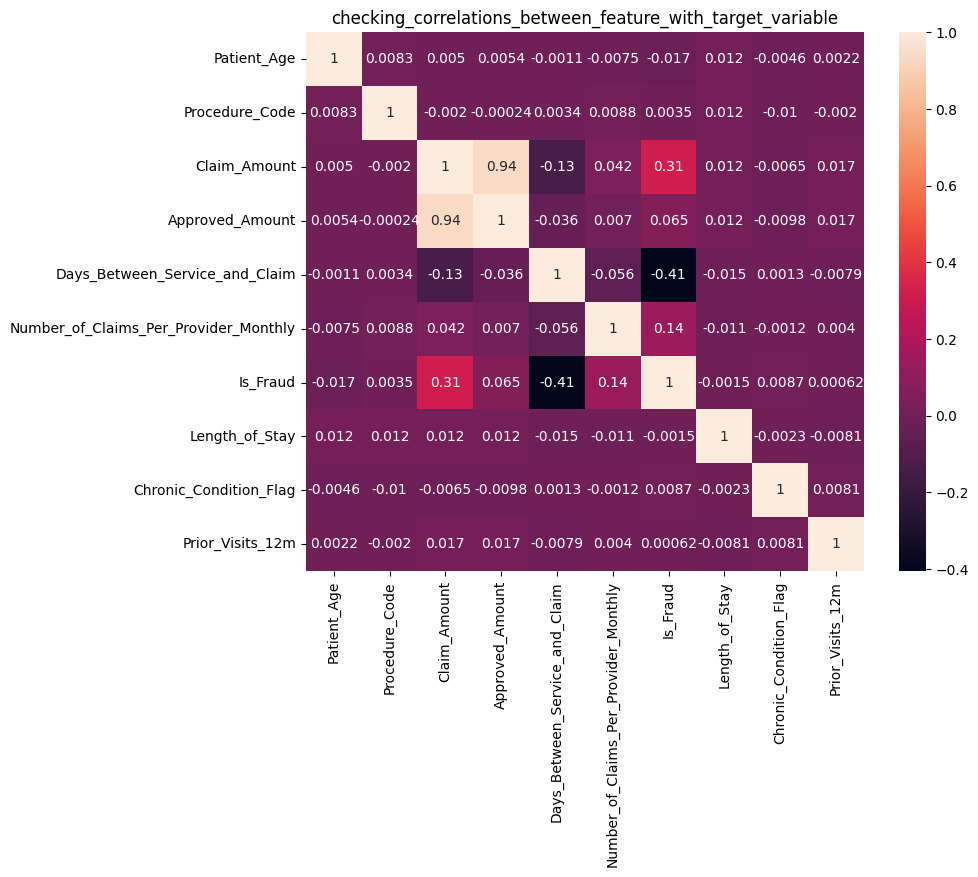

In [12]:
# Heatmap to check the relationship between target variable to features

corr_df =  health.corr(numeric_only=True)
plt.figure(figsize=(9,7))
sns.heatmap(corr_df , annot = True , color = 'red')
plt.title('checking_correlations_between_feature_with_target_variable')
plt.show()

In [13]:
# filling the missing categorical variablce with mode 

cols_cat = ['Insurance_Type','Provider_Specialty']
for col in cols_cat:
    health[col] = health[col].fillna(health[col].mode()[0])

In [14]:
# fill the missing numerica values with means 
health['Prior_Visits_12m'] = health['Prior_Visits_12m'].fillna(health['Prior_Visits_12m'].mean())

In [15]:
health.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 20 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Provider_ID                            10000 non-null  object 
 1   Claim_ID                               10000 non-null  object 
 2   Patient_Age                            10000 non-null  int64  
 3   Patient_Gender                         10000 non-null  object 
 4   Diagnosis_Code                         10000 non-null  object 
 5   Procedure_Code                         10000 non-null  int64  
 6   Claim_Amount                           10000 non-null  float64
 7   Approved_Amount                        10000 non-null  float64
 8   Insurance_Type                         10000 non-null  object 
 9   Claim_Submission_Date                  10000 non-null  object 
 10  Days_Between_Service_and_Claim         10000 non-null  int64  
 11  Num

In [16]:
# Rename_all the columns  captical letter into small letter 

health.columns = health.columns.str.lower()
health.head(4)

,provider_id,claim_id,patient_age,patient_gender,diagnosis_code,procedure_code,claim_amount,approved_amount,insurance_type,claim_submission_date,days_between_service_and_claim,number_of_claims_per_provider_monthly,provider_specialty,patient_state,claim_status,is_fraud,length_of_stay,visit_type,chronic_condition_flag,prior_visits_12m
0,P0052,C0000000,37,Male,I25.10,36415,443.51,393.16,Medicaid,2024-09-01,13,70,Cardiology,NY,Approved,0,0,Outpatient,1,2.0
1,P0121,C0000001,21,Female,E11.9,99213,467.50,461.33,Self-Pay,2022-09-05,5,62,General Practice,IL,Pending,0,5,Inpatient,1,2.0
2,P0140,C0000002,78,Female,J06.9,93000,591.69,530.06,Medicaid,2022-04-11,29,60,Cardiology,IL,Pending,0,5,Inpatient,1,3.0
3,P0202,C0000003,65,Male,I10,93000,235.15,189.11,Private,2023-10-11,22,70,General Practice,TX,Approved,0,0,Emergency,0,5.0


### Outlier check parts 

#### List of the columns here we are going the check the outlier 
---------------------------------------------------------------------------------------------------------------------------------
######  1.patient_age 
######  2.claim_amount
######  3.approve_amount
######  4.days_between_service_and_claim
######  5.number_of_claims_per_provider_monthly
######  6.length_of_stay
######  7.chronic_condition_flag
######  8.prior_visit_12m

---------------------------------------------------------------------------------------------------------------------------------------------

Based on my understanding of the data, these specific features are likely to contain outliers that could negatively impact model performance. If we do not address these outliers early, the model's predictive accuracy may be weakened.

It is essential to analyze these distributions now so we can decide whether to keep the values as they are, cap them (winsorization), or remove them to ensure the model remains robust and reliable.


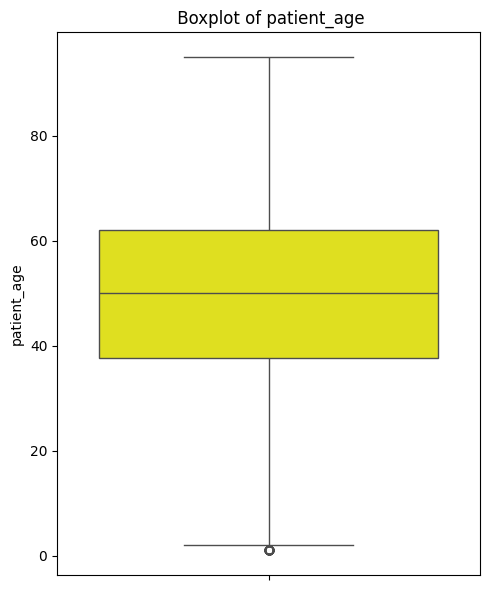

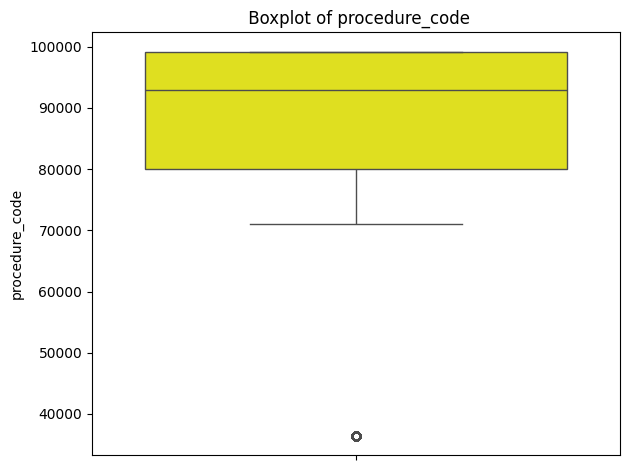

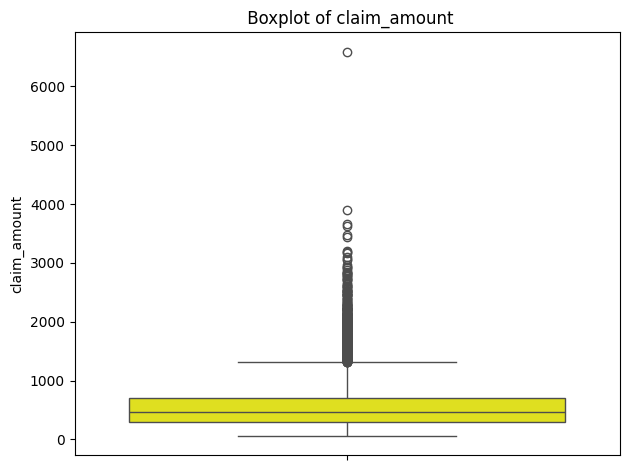

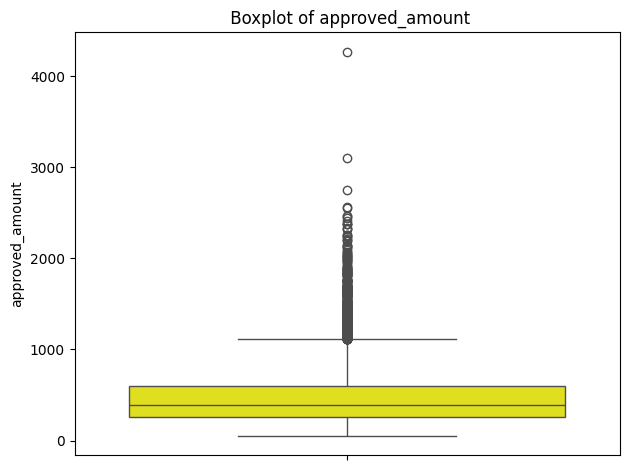

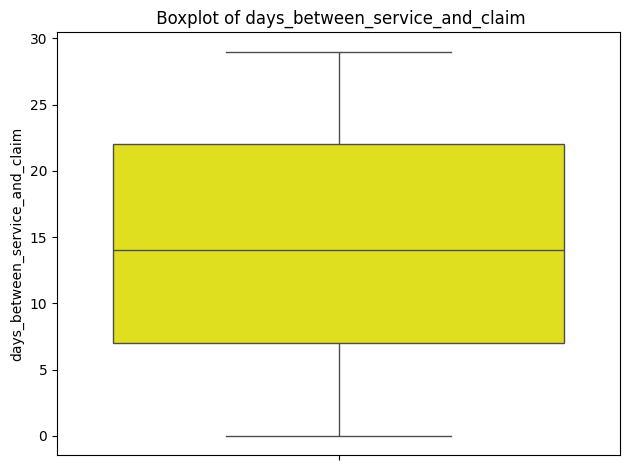

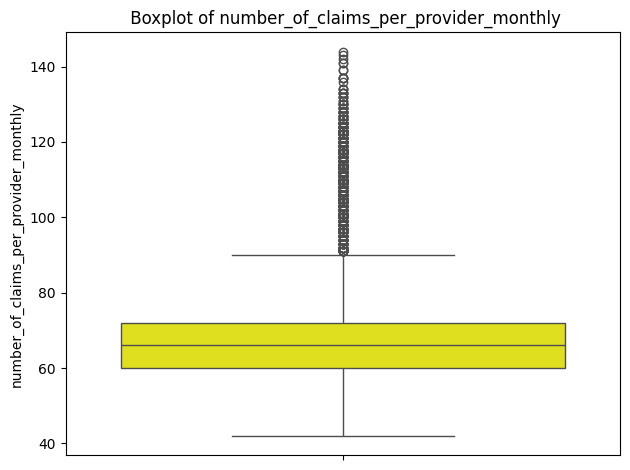

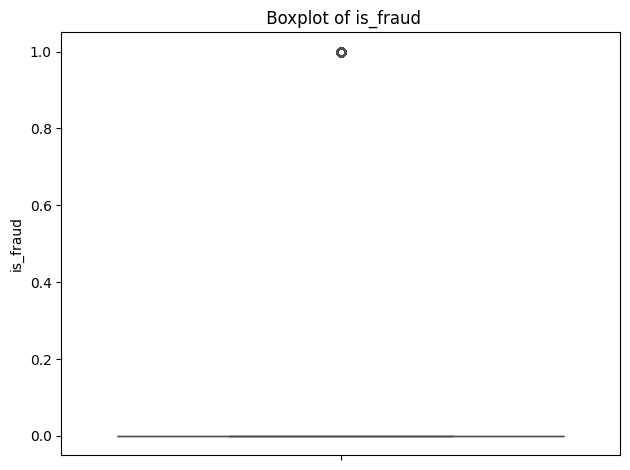

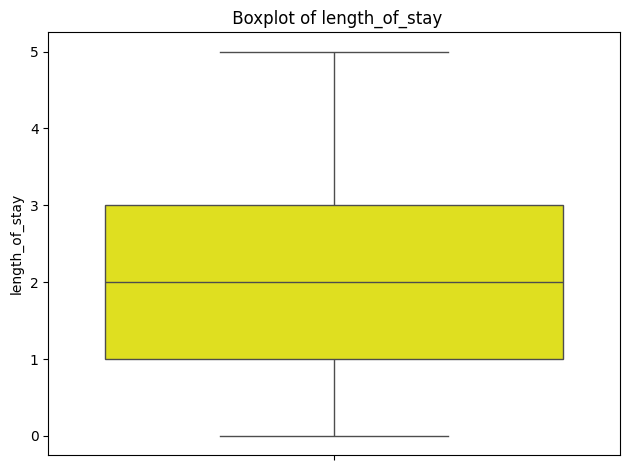

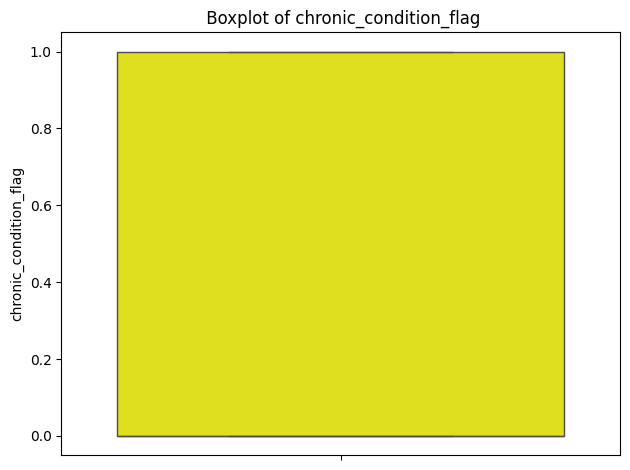

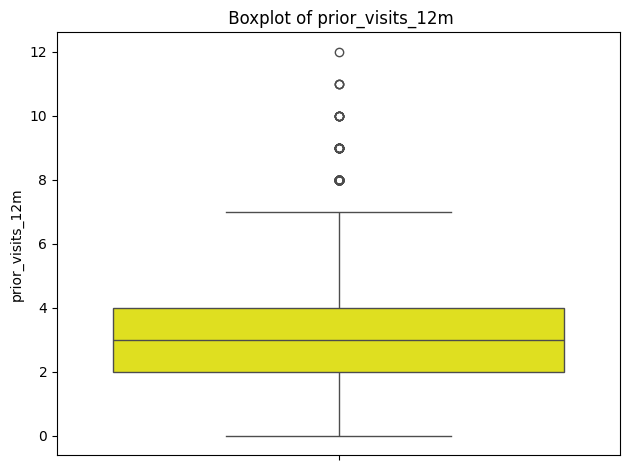

In [17]:
## Here the code
import math

outlier_check = health.select_dtypes(include=['int','float']).columns
plt.figure(figsize=(5,6))
for cols in outlier_check:
    sns.boxplot(health[cols], color='yellow')
    plt.title(f' Boxplot of {cols}')
    plt.tight_layout()
    plt.show()

     

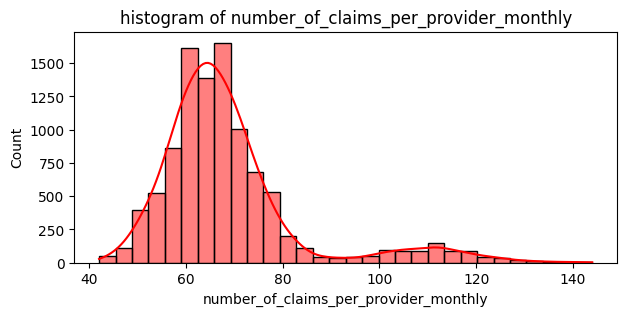

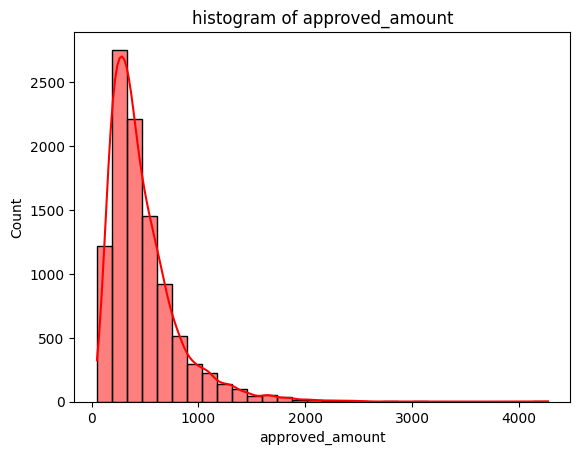

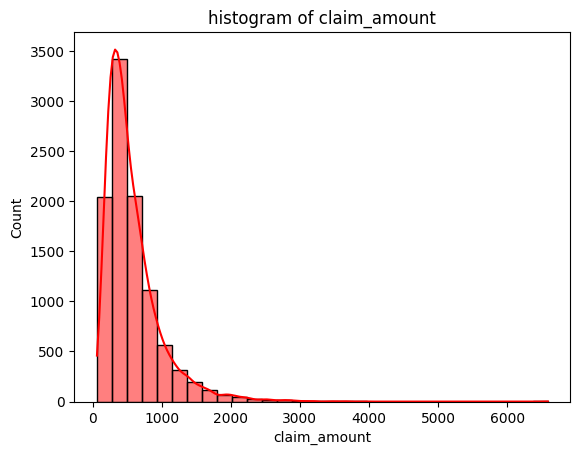

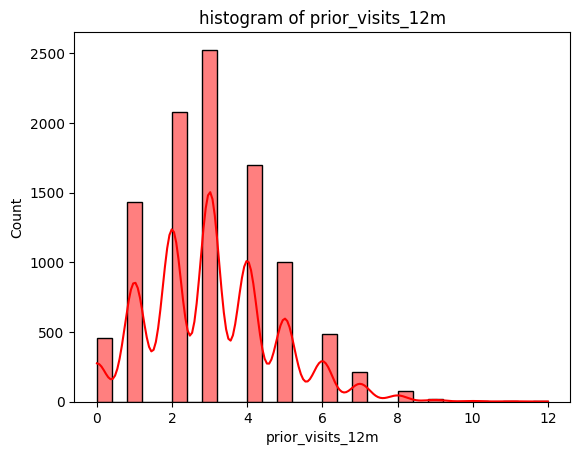

In [18]:
# here we are going check histogram of [-- number of claims per provider  monthly ,approved _amount, claim amount, prior visits 12m]

hist = ['number_of_claims_per_provider_monthly', 'approved_amount','claim_amount','prior_visits_12m']

plt.figure(figsize=(7,3))
for i in hist:
    sns.histplot(health[i] , bins=30 , color='red' , kde=True)
    plt.title(f'histogram of {i}')
    plt.show()

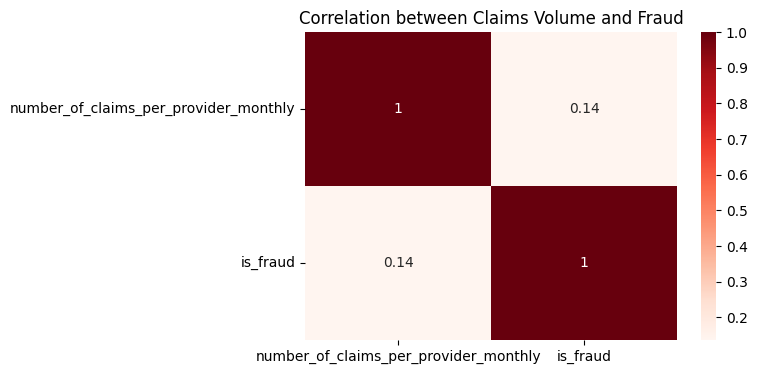

In [19]:
# 1. Select the columns
# 2. Calculate the correlation matrix
check = health[['number_of_claims_per_provider_monthly', 'is_fraud']].corr()

# 3. Plot the heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(check, annot=True, cmap='Reds') 
plt.title('Correlation between Claims Volume and Fraud')
plt.show()

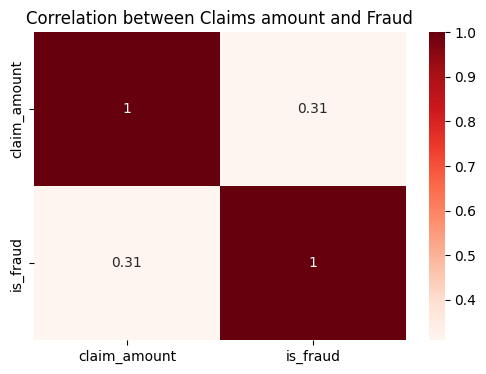

In [20]:
check = health[['claim_amount', 'is_fraud']].corr()

# 3. Plot the heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(check, annot=True, cmap='Reds') 
plt.title('Correlation between Claims amount and Fraud')
plt.show()

In [21]:
# Outlier are to be capped here  

# calculate the 99% percentile for our main columns
cap_claim = health['number_of_claims_per_provider_monthly'].quantile(0.99)
cap_approved = health['approved_amount'].quantile(0.99)
cap_claim_amt = health['claim_amount'].quantile(0.99)

health['number_of_claims_per_provider_monthly'] = health['number_of_claims_per_provider_monthly'].clip(upper=cap_claim)
health['approved_amount'] = health['approved_amount'].clip(upper=cap_approved)
health['claim_amount'] = health['claim_amount'].clip(upper=cap_claim_amt)

print(f'capping is complete , MAX Claim is now: {health['number_of_claims_per_provider_monthly'].max()}')

capping is complete , MAX Claim is now: 122


In [22]:
# 1. flag provider with more than 90 claim as 'high_volumne'

health['is_high_volume'] = (health['number_of_claims_per_provider_monthly']>90).astype(int)
# this claim intensity ratio about to check intesnity of money per claim
health['claim_intensity'] = health['approved_amount']/(health['number_of_claims_per_provider_monthly']+1)

#
health[['number_of_claims_per_provider_monthly','claim_intensity','is_high_volume','is_fraud']].head()

,number_of_claims_per_provider_monthly,claim_intensity,is_high_volume,is_fraud
0,70,5.537465,0,0
1,62,7.322698,0,0
2,60,8.689508,0,0
3,70,2.663521,0,0
4,67,5.439853,0,0


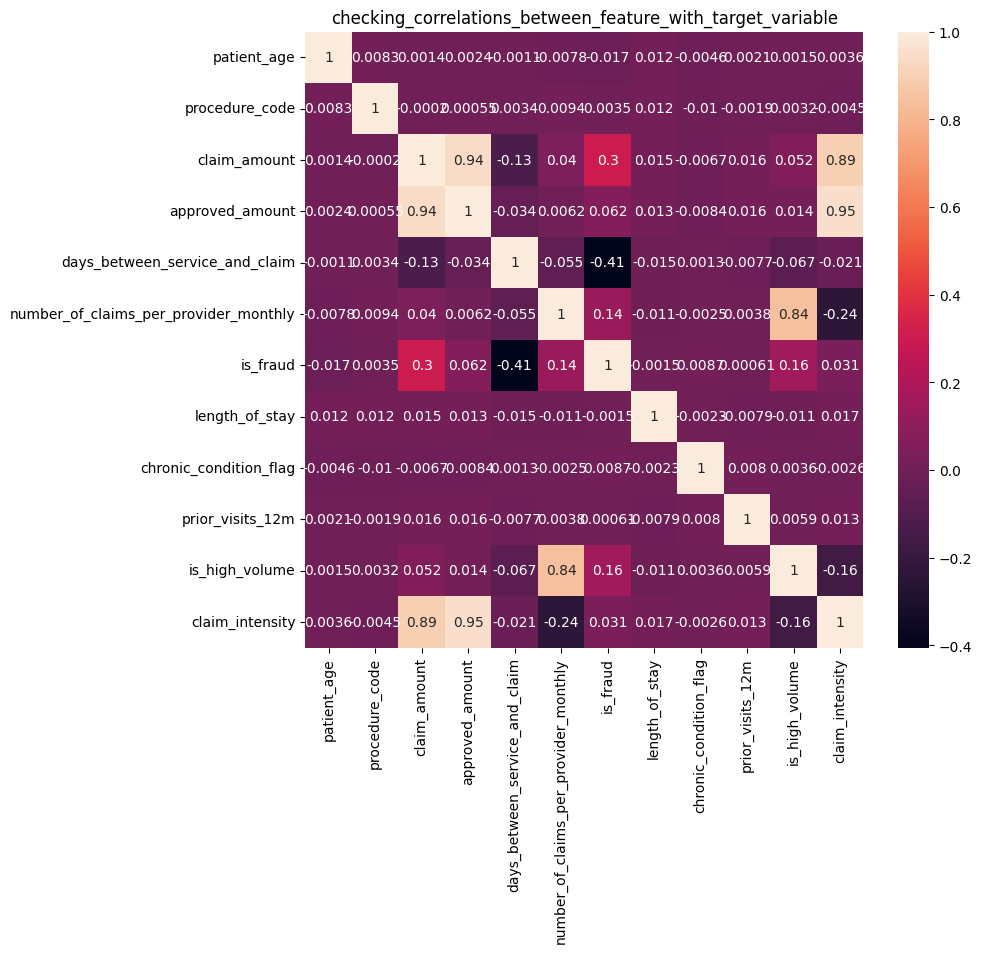

In [23]:
corr_dfs =  health.corr(numeric_only=True)
plt.figure(figsize=(9,8))
sns.heatmap(corr_dfs , annot = True , color = 'red')
plt.title('checking_correlations_between_feature_with_target_variable')
plt.show()

In [24]:
# create difference between claim amount & approved amount 
health['billing_gap'] = health['claim_amount'] - health['approved_amount']

# verify the columns

health.head(3)

,provider_id,claim_id,patient_age,patient_gender,diagnosis_code,procedure_code,claim_amount,approved_amount,insurance_type,claim_submission_date,...,patient_state,claim_status,is_fraud,length_of_stay,visit_type,chronic_condition_flag,prior_visits_12m,is_high_volume,claim_intensity,billing_gap
0,P0052,C0000000,37,Male,I25.10,36415,443.51,393.16,Medicaid,2024-09-01,...,NY,Approved,0,0,Outpatient,1,2.0,0,5.537465,50.35
1,P0121,C0000001,21,Female,E11.9,99213,467.50,461.33,Self-Pay,2022-09-05,...,IL,Pending,0,5,Inpatient,1,2.0,0,7.322698,6.17
2,P0140,C0000002,78,Female,J06.9,93000,591.69,530.06,Medicaid,2022-04-11,...,IL,Pending,0,5,Inpatient,1,3.0,0,8.689508,61.63


In [25]:

health['claim_submission_date'] = pd.to_datetime(health['claim_submission_date'] , errors = 'coerce')

health['claim_submission_date'].dtype

dtype('<M8[ns]')

## Phase 2  - feature scaling 

In [26]:
from sklearn.preprocessing  import StandardScaler , OneHotEncoder
from sklearn.svm import SVC
from sklearn.metrics import  f1_score , accuracy_score ,confusion_matrix ,classification_report
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# train & test split
from sklearn.model_selection import train_test_split
# tranformation
from sklearn.compose import ColumnTransformer

In [27]:
scaler = StandardScaler()
onehot = OneHotEncoder()

model = {'svm_classificer_model' : SVC(),
         'DecisionTreeClassifier' : DecisionTreeClassifier(max_depth=10, random_state=42,),
         'RandomForestClassifer': RandomForestClassifier(n_estimators=100, random_state=42) }
    

In [28]:
# Train & test split the dataset

x = health.drop(['provider_id' ,'claim_id' ,'claim_submission_date' , 'is_fraud'] , axis=1)
y= health['is_fraud']

In [29]:

# split the data into Train & test for model 

x_train ,x_test , y_train , y_test = train_test_split(x,y, test_size=0.2 , random_state=42)

In [30]:
# Identify which columns are numerical and which are categorical
# Note: Do NOT include 'is_fraud' here as it is already in y_train
numeric_features = x.select_dtypes(include=['int64', 'float64']).columns
categorical_features = x.select_dtypes(include=['object']).columns

preprocessor = ColumnTransformer(
    transformers=[
        ('num', scaler, numeric_features),
        ('cat', onehot, categorical_features)
    ])

# Fit and transform the training data, and transform the test data
x_train_transformed = preprocessor.fit_transform(x_train)
x_test_transformed = preprocessor.transform(x_test)

In [31]:
# converting them into datafram 
column_names = preprocessor.get_feature_names_out()
x_train_final = pd.DataFrame(x_train_transformed , columns= column_names)
x_test_final = pd.DataFrame(x_test_transformed , columns=column_names)

In [32]:
x_train_final

,num__patient_age,num__procedure_code,num__claim_amount,num__approved_amount,num__days_between_service_and_claim,num__number_of_claims_per_provider_monthly,num__length_of_stay,num__chronic_condition_flag,num__prior_visits_12m,num__is_high_volume,...,cat__patient_state_NY,cat__patient_state_OH,cat__patient_state_PA,cat__patient_state_TX,cat__claim_status_Approved,cat__claim_status_Pending,cat__claim_status_Rejected,cat__visit_type_Emergency,cat__visit_type_Inpatient,cat__visit_type_Outpatient
0,1.200151,0.018798,-0.255184,-0.121912,0.770770,-0.856672,0.466149,-0.645703,1.170004,-0.296384,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
1,1.144145,0.825949,-0.539417,-0.586545,-0.170251,-0.038253,0.466149,-0.645703,-0.602615,-0.296384,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
2,-0.648077,0.412391,-0.535951,-0.614794,0.065004,-1.470487,-0.704160,1.548700,-1.784361,-0.296384,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
3,1.424179,0.825882,0.050131,0.074144,0.065004,-0.856672,-1.289314,-0.645703,1.760876,-0.296384,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
4,2.488311,-1.048707,1.039980,0.975550,-1.581784,0.507361,-1.289314,-0.645703,1.760876,-0.296384,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7995,-1.152140,0.412391,0.750927,0.574940,-0.523135,-0.856672,-0.119006,-0.645703,0.579131,-0.296384,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
7996,-0.032001,-0.118367,0.475398,0.326277,-1.228901,-0.515664,-1.289314,1.548700,-0.602615,-0.296384,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
7997,-0.928112,0.825882,-0.058486,0.000262,-0.993646,3.440031,0.466149,1.548700,1.760876,3.374004,...,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0
7998,0.640082,0.412391,-0.294821,-0.337331,0.300260,-0.311059,-0.119006,-0.645703,0.579131,-0.296384,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0


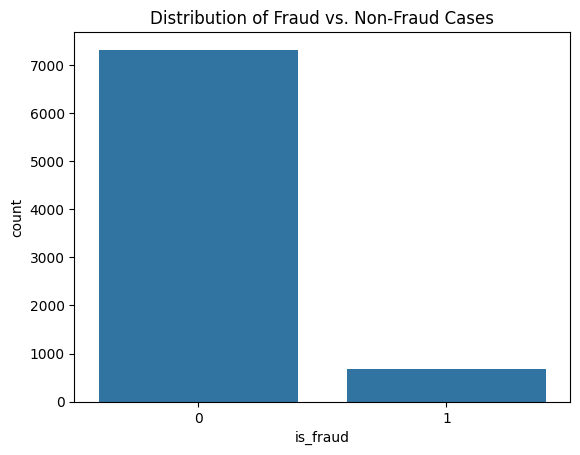

In [33]:
# check the comparison of the data see how many fraud & non-fraud case
sns.countplot(x=y_train)
plt.title('Distribution of Fraud vs. Non-Fraud Cases')
plt.show()

In [34]:
!pip install imbalanced-learn


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


New Class Distribution:
is_fraud
0    7324
1    7324
Name: count, dtype: int64


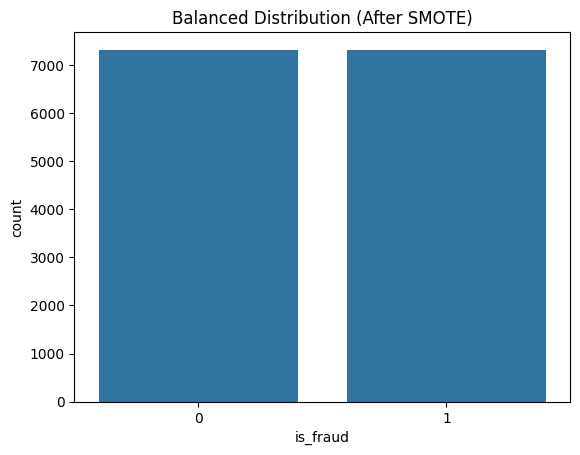

In [35]:
# chek the is there is any imbalance is there are not in order to get better accuracy
from imblearn.over_sampling import SMOTE

# Initialize SMOTE
smote = SMOTE(random_state=42)

# Resample the training data
x_train_resampled, y_train_resampled = smote.fit_resample(x_train_final, y_train)

# Check the new distribution
print("New Class Distribution:")
print(pd.Series(y_train_resampled).value_counts())

# Plot the new balanced distribution
sns.countplot(x=y_train_resampled)
plt.title('Balanced Distribution (After SMOTE)')
plt.show()

In [38]:
for name, clf in model.items():
    print(f"Training {name}...")
    clf.fit(x_train_resampled, y_train_resampled)
    y_pred = clf.predict(x_test_final)
    print(f"--- Classification Report for {name} ---")
    print(classification_report(y_test, y_pred))

Training svm_classificer_model...
--- Classification Report for svm_classificer_model ---
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1847
           1       0.92      0.91      0.91       153

    accuracy                           0.99      2000
   macro avg       0.96      0.95      0.95      2000
weighted avg       0.99      0.99      0.99      2000

Training DecisionTreeClassifier...
--- Classification Report for DecisionTreeClassifier ---
              precision    recall  f1-score   support

           0       1.00      0.99      0.99      1847
           1       0.86      0.95      0.90       153

    accuracy                           0.98      2000
   macro avg       0.93      0.97      0.95      2000
weighted avg       0.99      0.98      0.98      2000

Training RandomForestClassifer...
--- Classification Report for RandomForestClassifer ---
              precision    recall  f1-score   support

           0       

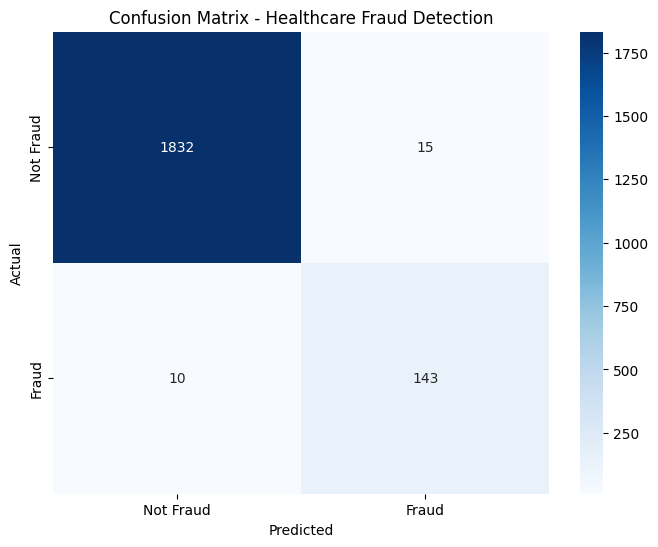

In [39]:
cm = confusion_matrix(y_test, y_pred)

# Plotting
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Not Fraud', 'Fraud'], 
            yticklabels=['Not Fraud', 'Fraud'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Healthcare Fraud Detection')
plt.show()

C:\Users\Test\AppData\Local\Temp\ipykernel_17740\1791596554.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(10), palette='viridis')


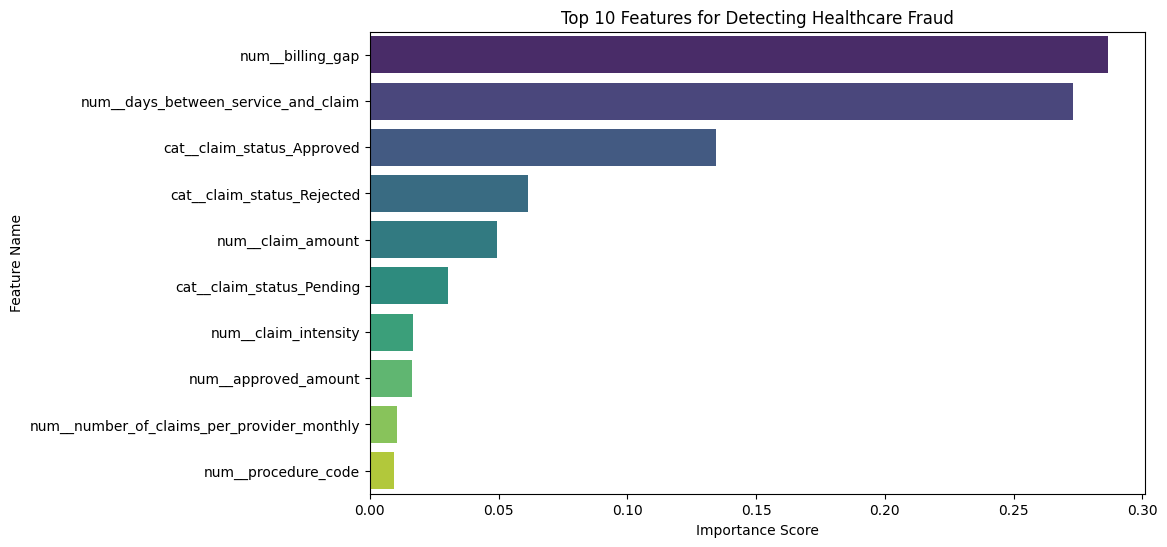

In [42]:
# Access the Random Forest specifically from your dictionary
importances = model['RandomForestClassifer'].feature_importances_
feature_names = x_train_final.columns

# 2. Create a DataFrame for easy plotting
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# 3. Plot the top 10 most important features
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(10), palette='viridis')
plt.title('Top 10 Features for Detecting Healthcare Fraud')
plt.xlabel('Importance Score')
plt.ylabel('Feature Name')
plt.show()

### Connect dataset to SQL to perform some KPI's 

In [43]:
from sqlalchemy import create_engine
import urllib

params = urllib.parse.quote_plus(
    "DRIVER={ODBC Driver 17 for SQL Server};"
    "SERVER=VIGNESH-JAGANAT\\SQLEXPRESS;"
    "DATABASE=health;"
    "Trusted_Connection=yes;"
)


engine = create_engine(f"mssql+pyodbc:///?odbc_connect={params}")

health.to_sql('deductor',engine,if_exists='replace',index=False)


81